In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolorsx
import os
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS

# from reproject import reproject_exact

from AstroColour.AstroColour import RGB

%matplotlib widget

In [2]:
ps1_data_list = []

for filt in ['i', 'r', 'g']:
    ps1_file = f'/Users/zgl12/Fig_Creation/rings.v3.skycell.2611.018.stk.{filt}.unconv.fits'
    ps1_hdul = fits.open(ps1_file)
    try:
        ps1_data = ps1_hdul[1].data
        ps1_wcs = WCS(ps1_hdul[1].header)
    except:
        ps1_data = ps1_hdul[0].data
        ps1_wcs = WCS(ps1_hdul[0].header)
    ps1_hdul.close()
    
    ps1_data_list.append(ps1_data)

In [3]:
rgb = RGB(ps1_data_list,
          save = False, save_name = 'test', save_folder = '/Users/zgl12/', 
          epsf_plot=False, epsf = False, manual_override = 0,
          bkg_plot = False, temp_save = False, run = False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..4.930139299505726].


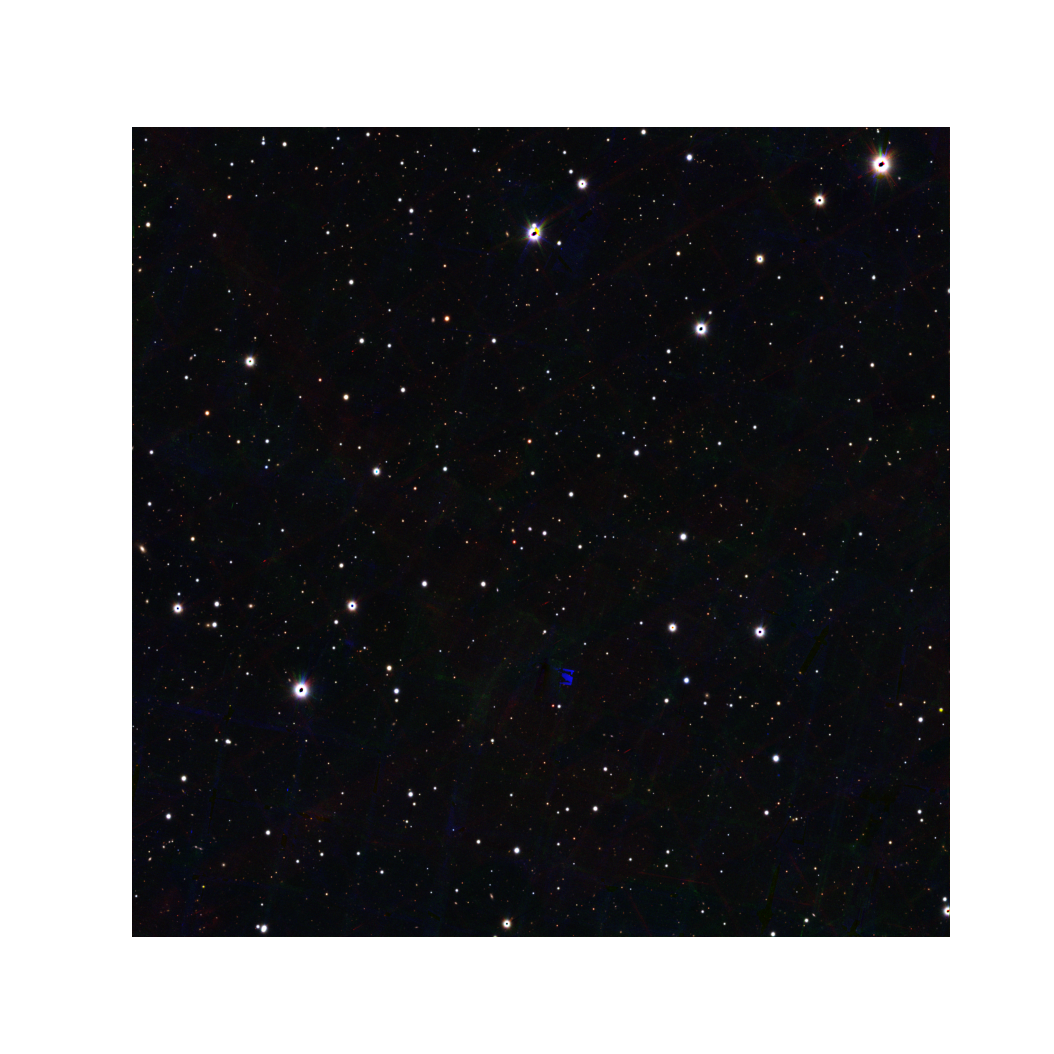

In [17]:
colour = rgb.master_plot(ps1_data_list, 
                         colours = ['red', 'green', 'blue'],
                         intensities = [0.6, 1, 0.56], 
                         gamma = [1.5, 1.5, 1.5],
                         norms = ['linear', 'linear', 'linear'], 
                         uppers = [99.5, 99.5, 99.5],
                         lowers = [40, 40, 40], 
                         interactive=False)

In [19]:
np.save('/Users/zgl12/Fig_Creation/colour.npy', colour)

In [18]:
colour.shape

(6398, 6452, 3)